# SSA Pipeline (ver.1)

## Phase 1

1. Create Hankel matrix of the segment of the signal
2. Apply SVD on the Hankel matrix
3. Select the appropriate number of singular components using singual value variance (>95%)
4. Reconstruct the extracted segment of the signal (mECG)

## Phase 2

5. Find peaks and remove them from mECG (Note: at this point, overlapping peaks with fECG will disappear)
6. Repeat the procedure from Phase 1 to extract the second ECG (fECG)

In [133]:
from scipy.linalg import hankel, svd
from tensorly.decomposition import tucker

import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
import tensorly as tl

import os, wget
import pyedflib

In [134]:
# # Run this cell only if you need to download the dataset
# !cd .. && mkdir data\raw && cd data\raw
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r01.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r04.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r07.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r08.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r10.edf

In [135]:
# please run EdfReader only once otherwise it will throw an error
edf_path = os.path.join("..", "data", "raw", "r01.edf")

try:
    edf = pyedflib.EdfReader(edf_path)
except:
    edf._close()
    del edf
    edf = pyedflib.EdfReader(edf_path)

In [136]:
# useful functions
def get_signal_segment(ch_number: int = 0, start_time: float = 0, end_time: float = 5):
    sampling_rate = edf.getSampleFrequency(ch_number)
    signal = edf.readSignal(ch_number)
    onsets, _, _ = edf.readAnnotations()
    
    start_index = int(start_time * sampling_rate)
    end_index = int(end_time * sampling_rate)
    
    signal_segment = signal[start_index:end_index]
    time_segment = np.linspace(start_time, end_time, len(signal_segment))
    
    onsets_in_segment = onsets[(onsets >= start_time) & (onsets <= end_time)]
    onset_values = np.interp(onsets_in_segment, time_segment, signal_segment)
    
    return signal_segment, time_segment, onsets_in_segment, onset_values

def plot_signal(
    signal: np.ndarray,
    time: np.ndarray,
    onsets: np.ndarray = None,
    onsets_values: np.ndarray = None,
    title: str = "ECG Signal Segment",
    xlabel: str = "Time (s)",
    ylabel: str = "Amplitude (µV)",
    figsize: tuple = (15, 5),
    filename: str = None
):
    plt.figure(figsize=figsize)
    plt.plot(time, signal, label="ECG Signal")
    
    if onsets is not None and onsets_values is not None:
        plt.scatter(onsets, onsets_values, color="red", label="R-peaks", zorder=5)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid()
    
    if filename:
        plt.savefig(filename)
    plt.show()
    
def hankelize_and_extract(signal: np.ndarray, window_size: int = 625*2, cvp: int = 75) -> np.ndarray:
    # create the Hankel matrix of the given signal
    L = window_size
    H = hankel(signal[:L], signal[L-1:])
    
    # perform SVD on the Hankel matrix
    U, S, VT = svd(H, full_matrices=False)
    
    # calculate explained variances and determine number of components to retain
    variances = S**2 / (H.shape[0]-1)
    explained_variances = variances / np.sum(variances)
    cumulative_variance_percentage = np.cumsum(explained_variances) * 100
    
    n_components = np.argmax(cumulative_variance_percentage >= cvp) + 1

    # reconstruct the signal using the selected number of components
    R = U[:, 0:n_components] @ np.diag(S[0:n_components]) @ VT[0:n_components, :]

    L = R.shape[0]
    K = R.shape[1]
    M = L + K - 1

    # initialize the reconstructed signal array
    extracted_signal = np.zeros(M)
    count = np.zeros(M) # array to keep track of how many elements contributed to the average

    # iterate through every element of the reconstructed matrix R
    for i in range(L):
        for j in range(K):
            # the anti-diagonal index (m) is i + j
            m = i + j
            
            # accumulate the value and the count for this anti-diagonal
            extracted_signal[m] += R[i, j]
            count[m] += 1

    # divide the accumulated sum by the count to get the average
    extracted_signal /= count
    
    return extracted_signal


def interpolate_peaks(signal: np.ndarray, sampling_rate: int = 1000, peaks: np.ndarray = [], show: bool = False) -> np.ndarray:
    _, info = nk.ecg_peaks(-signal, sampling_rate=sampling_rate, correct_artifacts=True)
    
    clean_signal = signal.copy()
    for i in range(len(peaks)):
        clean_signal[peaks[i]-70:peaks[i]+70] = signal[peaks[i]-70:peaks[i]+70] * 0.1
    if show:
        plt.figure(figsize=(15, 5))
        plt.plot(clean_signal, color='grey', alpha=0.7)
        plt.plot(signal, color='orange', alpha=0.3)
    
    return clean_signal

def analyze_signal_quality(signal: np.ndarray, sampling_rate: int = 1000, cvp_values: list = [70, 75, 80, 85, 90, 95], window_size: int = 625*2) -> tuple:
    cvps = []
    for cvp in cvp_values:
        # print("Creating Hankel matrix with CVP =", cvp)
        cvps.append(hankelize_and_extract(signal, window_size=window_size, cvp=cvp))
        
    signals_quality = []
    # print("Calculating quality...")
    for s in cvps:    
        s_quality = nk.ecg_quality(s, sampling_rate=sampling_rate)
        signals_quality.append(s_quality.mean())
        
    best_signal = cvps[np.argmax(signals_quality)]
    
    return cvp_values[np.argmax(signals_quality)], best_signal, signals_quality

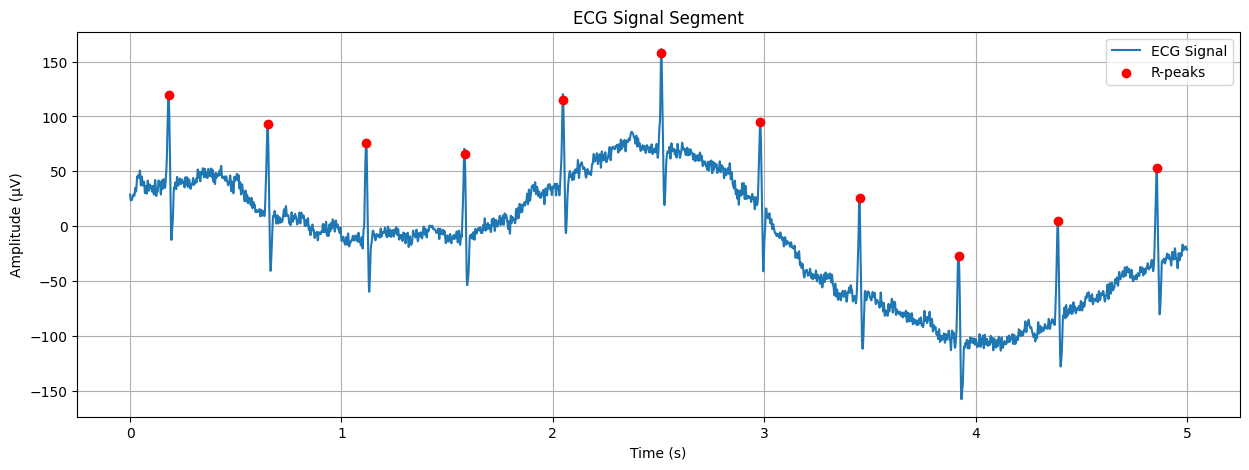

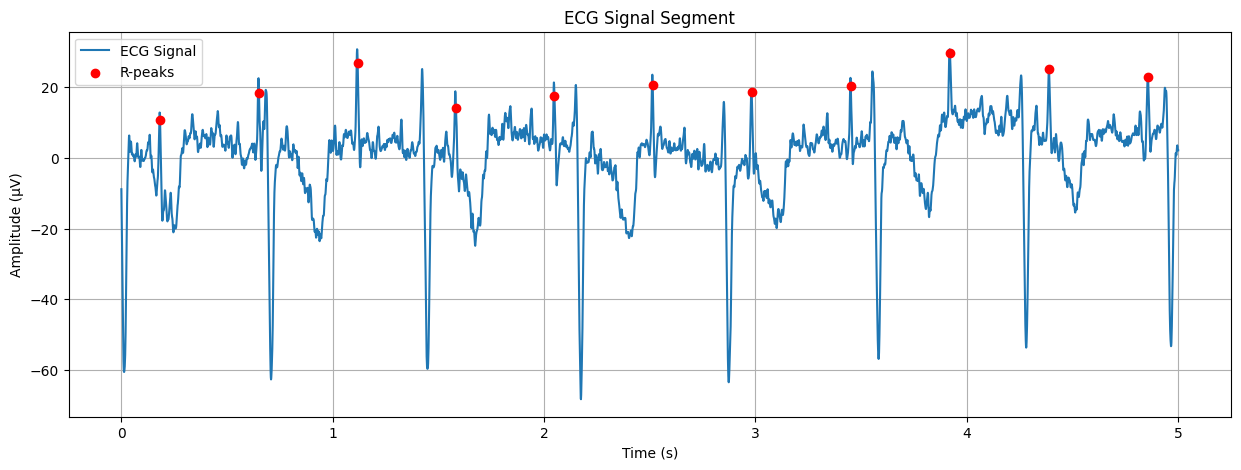

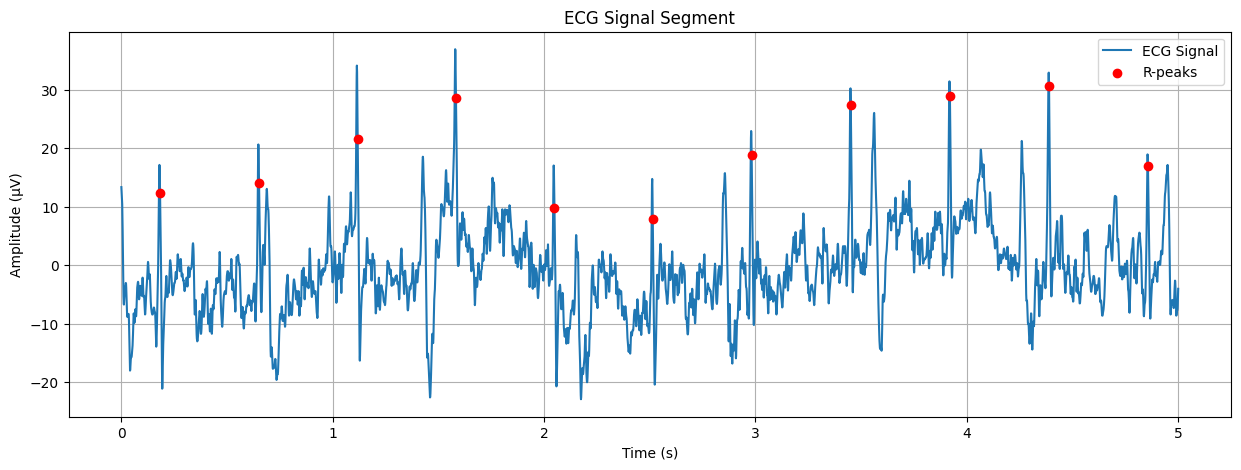

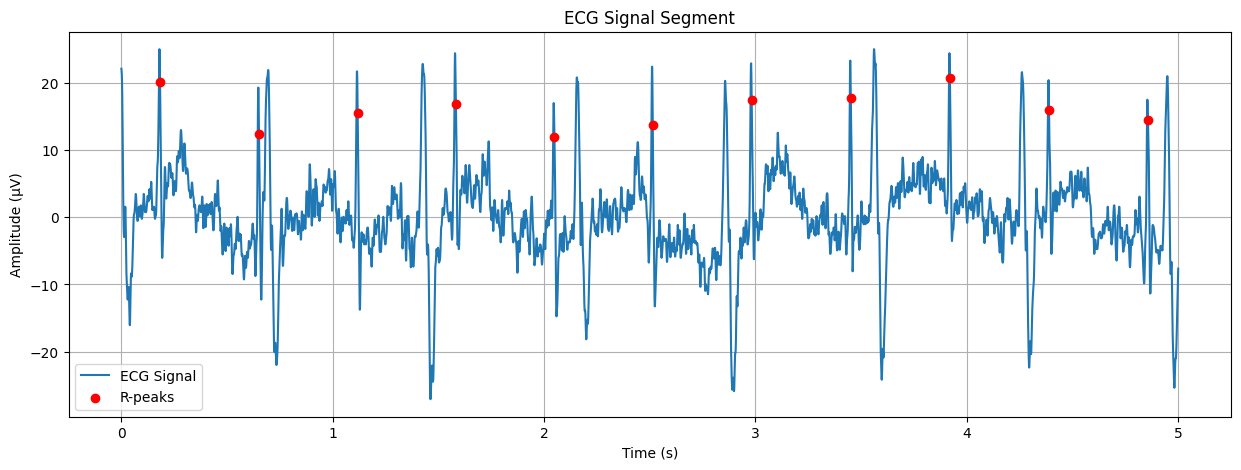

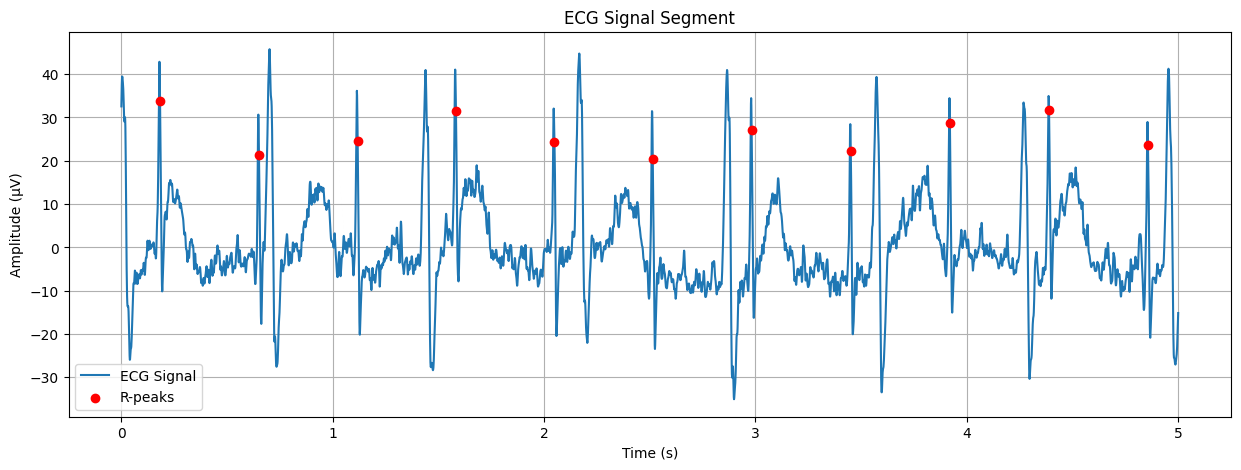

In [137]:
direct_segment, time_segment, onsets, onsets_values = get_signal_segment(ch_number=0)
abdomen_segment_1, time_segment_1, onsets_1, onsets_values_1 = get_signal_segment(ch_number=1)
abdomen_segment_2, time_segment_2, onsets_2, onsets_values_2 = get_signal_segment(ch_number=2)
abdomen_segment_3, time_segment_3, onsets_3, onsets_values_3 = get_signal_segment(ch_number=3)
abdomen_segment_4, time_segment_4, onsets_4, onsets_values_4 = get_signal_segment(ch_number=4)

plot_signal(direct_segment, time_segment, onsets, onsets_values)
plot_signal(abdomen_segment_1, time_segment_1, onsets_1, onsets_values_1)
plot_signal(abdomen_segment_2, time_segment_2, onsets_2, onsets_values_2)
plot_signal(abdomen_segment_3, time_segment_3, onsets_3, onsets_values_3)
plot_signal(abdomen_segment_4, time_segment_4, onsets_4, onsets_values_4)

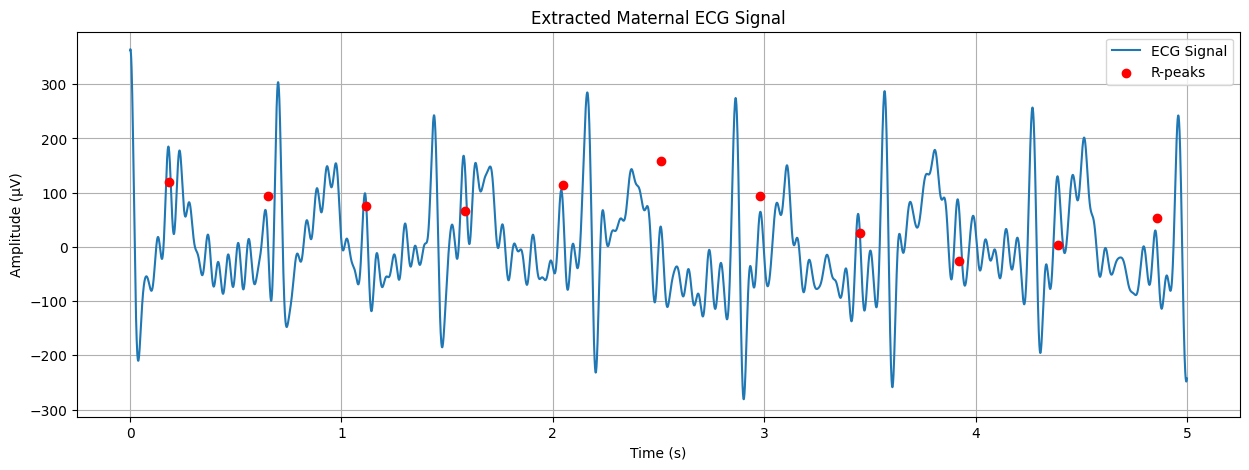

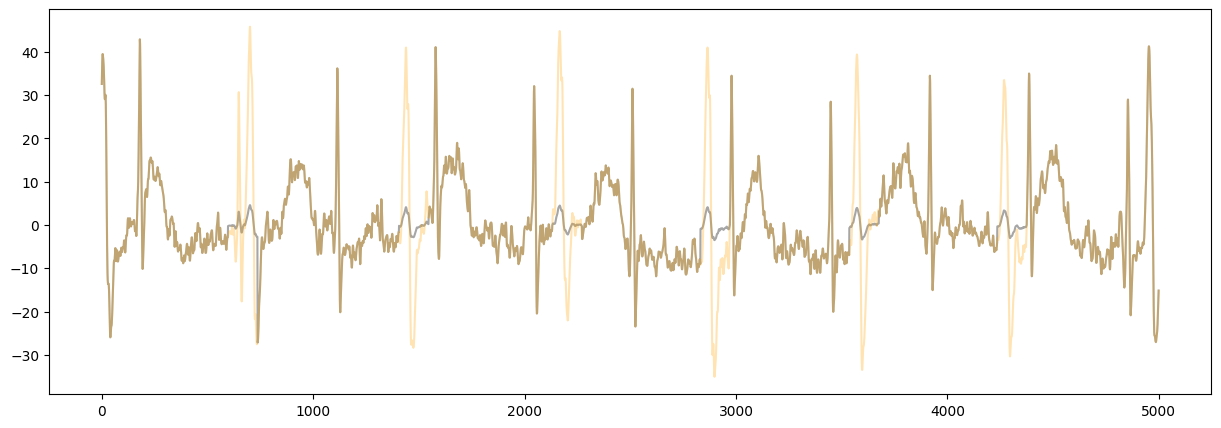

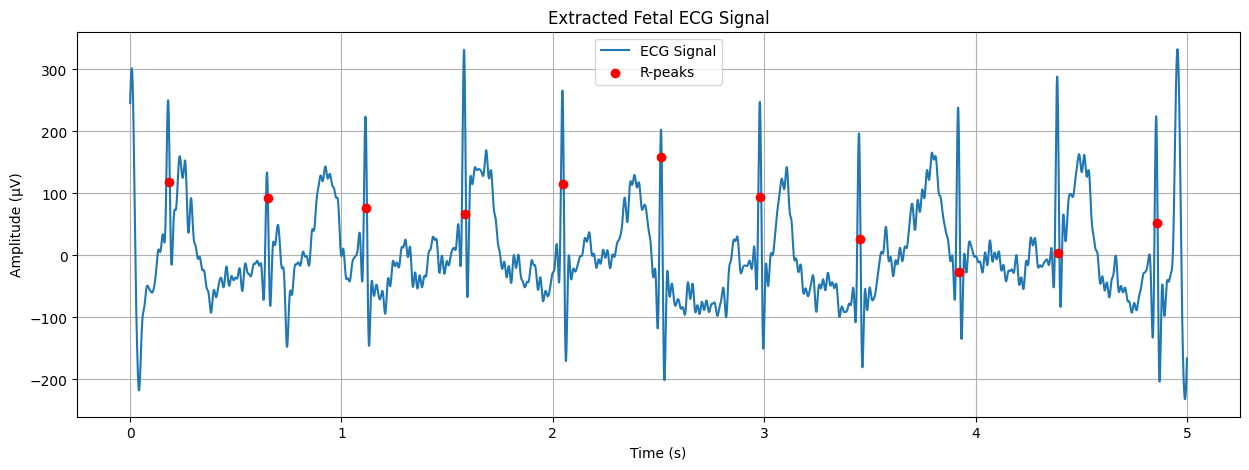

In [138]:
# This signal has 8 beats in 5 seconds for the mother and 15 beats for the fetus
# 8/5 = 1.6 -> 1/1.6 = 0.625 -> 0.625 * 1000 = 625 samples
# 11/5 = 2.2 -> 1/2.2 = 0.454 -> 0.454 * 1000 = 454 samples

mecg = hankelize_and_extract(abdomen_segment_4, window_size=625*2, cvp=70)
mecg_signals, mecg_info = nk.ecg_peaks(-mecg, sampling_rate=1000, correct_artifacts=True, method="emrich2023")
plot_signal(mecg*10, np.linspace(0, len(mecg)/1000, len(mecg)), onsets, onsets_values, title="Extracted Maternal ECG Signal")

# residual_signal = abdomen_segment_1 - mecg*2.5

_, info = nk.ecg_peaks(-mecg, sampling_rate=1000, correct_artifacts=True)
mecg_peaks = info['ECG_R_Peaks']
residual_signal = interpolate_peaks(abdomen_segment_4, peaks=mecg_peaks, show=True)

fecg = hankelize_and_extract(residual_signal, window_size=454*2, cvp=90)
fecg_signals, fecg_info = nk.ecg_peaks(-fecg, sampling_rate=1000, correct_artifacts=True)
plot_signal(fecg*10, np.linspace(0, len(fecg)/1000, len(fecg)), onsets, onsets_values, title="Extracted Fetal ECG Signal")

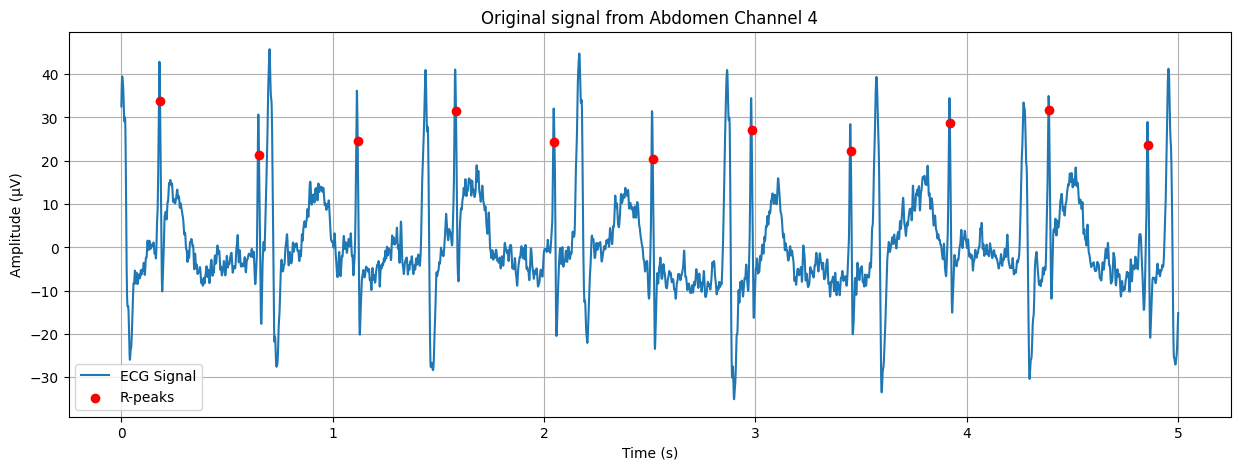

In [139]:
plot_signal(abdomen_segment_4, time_segment_4, onsets_4, onsets_values_4, title="Original signal from Abdomen Channel 4")

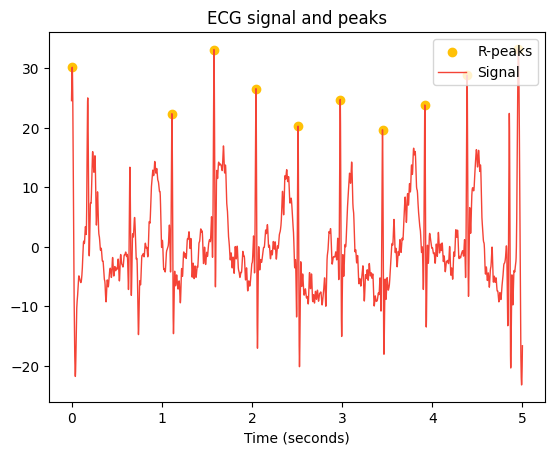

In [140]:
_, _ = nk.ecg_peaks(fecg, sampling_rate=1000, correct_artifacts=True, method="emrich2023", show=True)

## Signal quality (test)

We can also assess the quality of a signal in a quantitative way

In [141]:
abdomen_signals = [
    abdomen_segment_1,
    abdomen_segment_2,
    abdomen_segment_3,
    abdomen_segment_4
]

best_signals = []
for signal in abdomen_signals:
    best_cvp, best_signal, signals_quality = analyze_signal_quality(signal)
    print(f"Best CVP: {best_cvp} with quality scores: {np.argmax(signals_quality)}")
    best_signals.append(best_signal)

Best CVP: 75 with quality scores: 1
Best CVP: 95 with quality scores: 5
Best CVP: 95 with quality scores: 5
Best CVP: 70 with quality scores: 0


## Opzione A: concatenazione e SVD classica

In [142]:
L = 625*2
H1 = hankel(abdomen_segment_1[:L], abdomen_segment_1[L-1:])
H2 = hankel(abdomen_segment_2[:L], abdomen_segment_2[L-1:])
H3 = hankel(abdomen_segment_3[:L], abdomen_segment_3[L-1:])
H4 = hankel(abdomen_segment_4[:L], abdomen_segment_4[L-1:])

abdomen_signals = np.array([H1, H2, H3, H4])
abdomen_signals.shape

(4, 1250, 3751)

Selected components:
 - mECG: 1..36
 - fECG: 37..82
 - Noise: >82


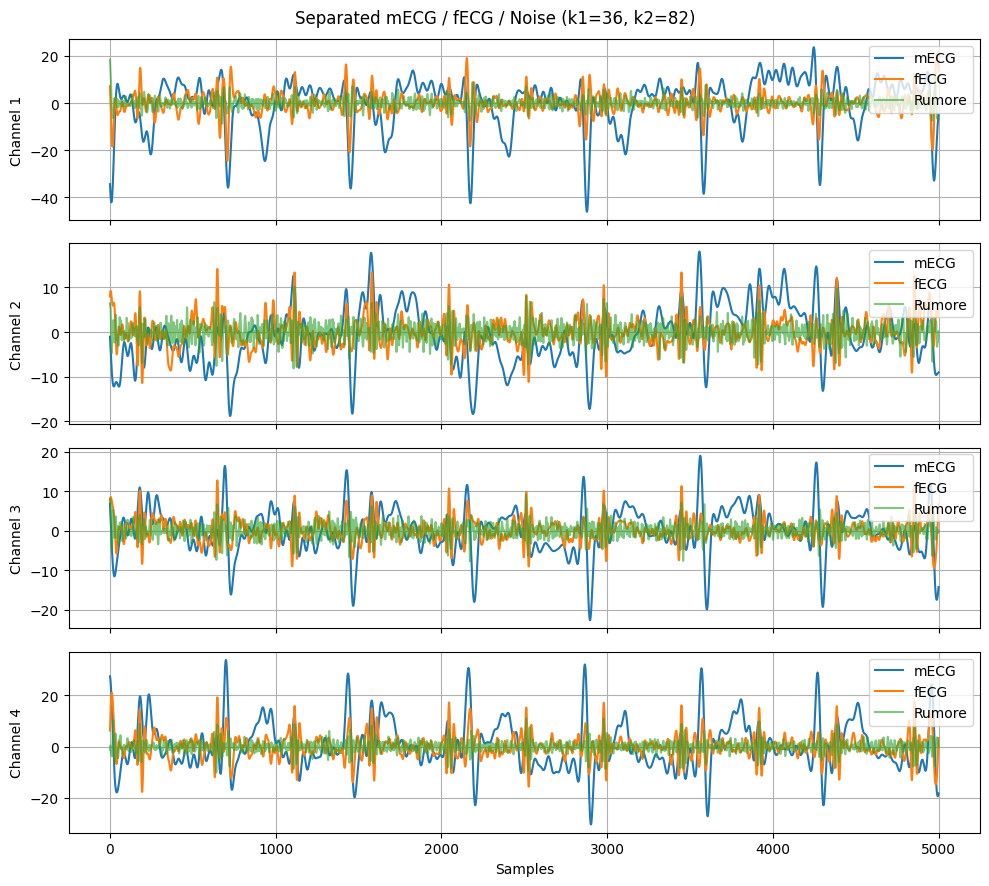

In [ ]:
# concat of 4 hankel matrices
H = np.hstack((H1, H2, H3, H4))
L, K = H1.shape

# svd
U, s, Vt = np.linalg.svd(H, full_matrices=False)

# explained variance
var_explained = s**2 / np.sum(s**2)
cumulative_var = np.cumsum(var_explained)

# select components to extract for mecg and fecg
k1 = np.argmax(cumulative_var >= 0.75) + 1   # mECG
k2 = np.argmax(cumulative_var >= 0.95) + 1   # fECG
print(f"Selected components:")
print(f" - mECG: 1..{k1}")
print(f" - fECG: {k1+1}..{k2}")
print(f" - Noise: >{k2}")

# partial reconstructions
H_mecg = U[:, :k1] @ np.diag(s[:k1]) @ Vt[:k1, :]
H_fecg = U[:, k1:k2] @ np.diag(s[k1:k2]) @ Vt[k1:k2, :]
H_noise = U[:, k2:] @ np.diag(s[k2:]) @ Vt[k2:, :]

# diagonal averaging
def diagonal_averaging(H):
    L, K = H.shape
    N = L + K - 1
    x_rec = np.zeros(N)
    counts = np.zeros(N)
    for i in range(L):
        for j in range(K):
            x_rec[i + j] += H[i, j]
            counts[i + j] += 1
    return x_rec / counts

# reconstruct each channel
def reconstruct_channels(H_block):
    reconstructed = []
    for c in range(4):
        start_col = c * K
        end_col = (c + 1) * K
        Hc = H_block[:, start_col:end_col]
        x_rec = diagonal_averaging(Hc)
        reconstructed.append(x_rec)
    return reconstructed

mECG_signals = reconstruct_channels(H_mecg)
fECG_signals = reconstruct_channels(H_fecg)
noise_signals = reconstruct_channels(H_noise)

# plot results
fig, axs = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
for c in range(4):
    axs[c].plot(mECG_signals[c], color='C0', label='mECG')
    axs[c].plot(fECG_signals[c], color='C1', label='fECG')
    axs[c].plot(noise_signals[c], color='C2', alpha=0.6, label='Rumore')
    axs[c].legend(loc='upper right')
    axs[c].grid(True)
    axs[c].set_ylabel(f'Channel {c+1}')

axs[-1].set_xlabel('Samples')
plt.suptitle(f'Separated mECG / fECG / Noise (k1={k1}, k2={k2})')
plt.tight_layout()
plt.show()

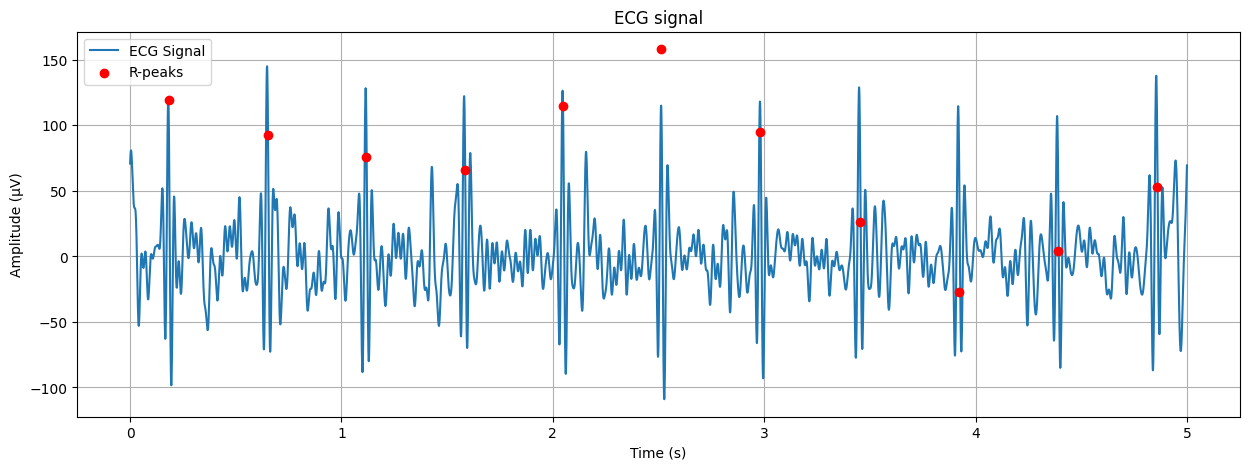

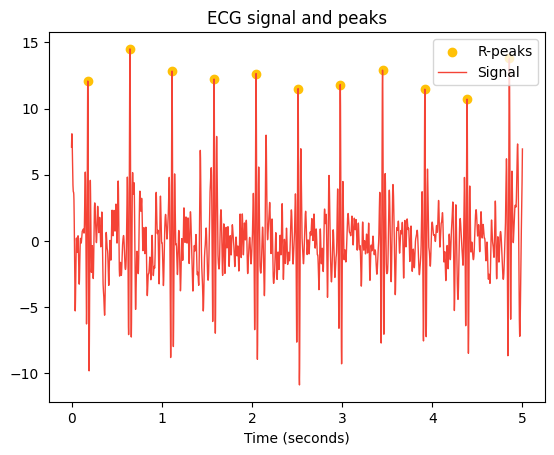

In [144]:
# mean and weighted combination
mECG_mean = np.mean(np.array(mECG_signals), axis=0)
fECG_mean = np.mean(np.array(fECG_signals), axis=0)
noise_mean = np.mean(np.array(noise_signals), axis=0)

quality = np.array([0.57, 0.50, 0.59, 0.74])
weights = quality / np.sum(quality)
mECG_combined = np.sum(np.array(mECG_signals) * np.array(weights)[:, None], axis=0)
fECG_combined = np.sum(np.array(fECG_signals) * np.array(weights)[:, None], axis=0)
noise_combined = np.sum(np.array(noise_signals) * np.array(weights)[:, None], axis=0)

time = np.linspace(0, len(mECG_mean)/1000, len(mECG_mean))  # fs = 1000 Hz

plot_signal(fECG_combined*10, time, onsets=onsets, onsets_values=onsets_values, title="ECG signal")
_, _ = nk.ecg_peaks(fECG_combined, sampling_rate=1000, correct_artifacts=True, method="emrich2023", show=True)


## Opzione B: stack come tensore e decomposizione tensoriale

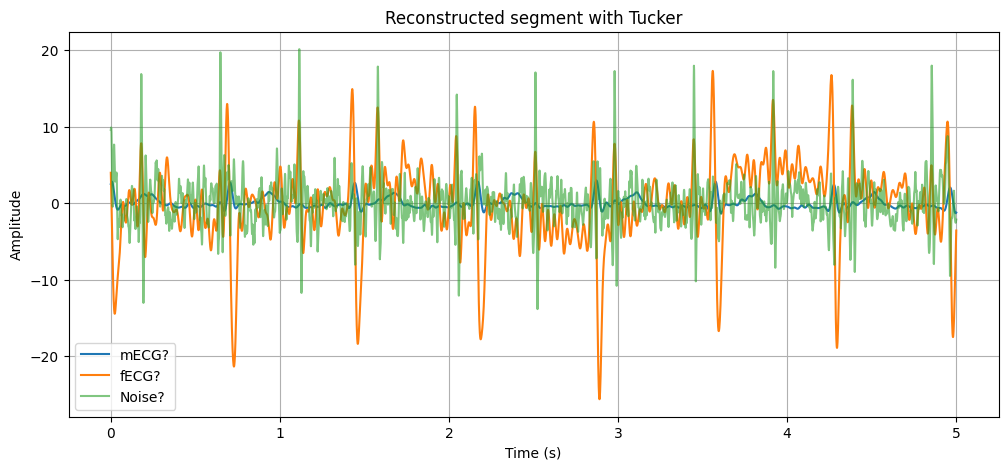

In [145]:
H_tensor = np.stack([H1, H2, H3, H4], axis=2)  # shape (L, K, 4)
L, K, C = H_tensor.shape

quality = np.array([0.57, 0.50, 0.59, 0.74])
weights = quality / np.sum(quality)

# tucker decomposition
rank = [min(50, L), min(50, K), 4]
core, factors = tucker(H_tensor, rank=rank)

U_L, U_K, U_C = factors

# signal separation
S_mecg = np.zeros_like(core)
S_mecg[:, :, 0] = core[:, :, 0]  # first component

S_fecg = np.zeros_like(core)
S_fecg[:, :, 1:] = core[:, :, 1:]  # rest of components

# reconstruct partial tensors
H_mecg = tl.tucker_to_tensor((S_mecg, factors))
H_fecg = tl.tucker_to_tensor((S_fecg, factors))
H_noise = H_tensor - (H_mecg + H_fecg)  # residual

# diagonal averaging
def diagonal_averaging(H):
    L, K = H.shape
    N = L + K - 1
    x_rec = np.zeros(N)
    counts = np.zeros(N)
    for i in range(L):
        for j in range(K):
            x_rec[i + j] += H[i, j]
            counts[i + j] += 1
    return x_rec / counts

def reconstruct_channels(H_block):
    L, K, C = H_block.shape
    reconstructed = []
    for c in range(C):
        x_rec = diagonal_averaging(H_block[:, :, c])
        reconstructed.append(x_rec)
    return reconstructed

mECG_signals = reconstruct_channels(H_mecg)
fECG_signals = reconstruct_channels(H_fecg)
noise_signals = reconstruct_channels(H_noise)

# weighted combination
mECG_combined = np.sum(np.array(mECG_signals) * weights[:, None], axis=0)
fECG_combined = np.sum(np.array(fECG_signals) * weights[:, None], axis=0)
noise_combined = np.sum(np.array(noise_signals) * weights[:, None], axis=0)

# plot results
time = np.linspace(0, len(mECG_combined)/1000, len(mECG_combined))  # fs=1000 Hz

plt.figure(figsize=(12,5))
plt.plot(time, mECG_combined, label='mECG?', color='C0')
plt.plot(time, fECG_combined, label='fECG?', color='C1')
plt.plot(time, noise_combined, label='Noise?', color='C2', alpha=0.6)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Reconstructed segment with Tucker')
plt.legend()
plt.grid(True)
plt.show()


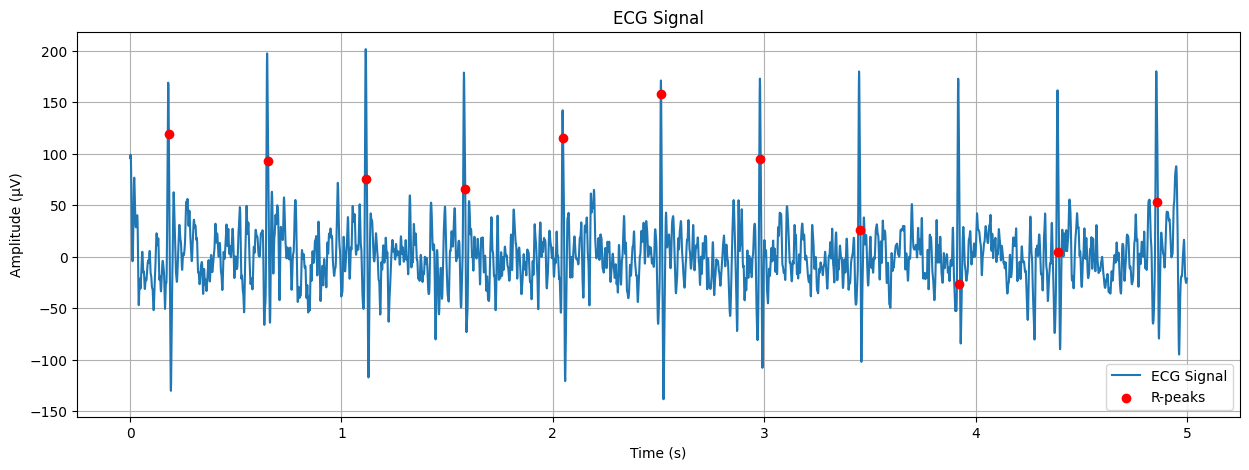

In [146]:
plot_signal(noise_combined*10, time, onsets=onsets, onsets_values=onsets_values, title="ECG Signal")
